# 📝 Credit Risk Classification

## The Business Problem:
Imagine you work in a bank's risk department. Thousands of credit card applications arrive every day. Approving a customer who subsequently defaults (a delinquent payer) costs the bank a significant amount of money. Rejecting a good customer means losing revenue to the competition.

## Objective:
 We are going to build a machine learning model capable of classifying a customer as "High Risk" (Label = 1) or "Low Risk" (Label = 0) based on their demographic and financial data before granting them the card.

## The Dataset:

It is available at the following link: https://www.kaggle.com/datasets/rohitudageri/credit-card-details/data

1. `Credit_card.csv`: Contains the covariates (customer characteristics such as income, marital status, age, etc.).
2. `Credit_card_label.csv`: Contains the target/response variable (whether the customer was "good" or "bad").

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models.  
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

#### Load the data and merge

In [2]:
df_features = pd.read_csv('/Users/danielmercedes/Documents/Jyts/Credit_card_data/Credit_card.csv')
df_labels= pd.read_csv('/Users/danielmercedes/Documents/Jyts/Credit_card_data/Credit_card_label.csv')

df = pd.merge(df_features, df_labels, on= 'Ind_ID', how= 'inner')

df.shape

(1548, 19)

In [3]:
# Check for duplicates values

df.duplicated().sum()

np.int64(0)

In [4]:
df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2,1
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2,1
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1


In [5]:
# Low-risk clients label = 0, high-risk clients label = 1
# The majority of the clients are low-risk.

df['label'].value_counts(normalize=True)

label
0    0.886951
1    0.113049
Name: proportion, dtype: float64

In [6]:
df.describe()

,Ind_ID,CHILDREN,Annual_income,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Family_Members,label
count,1.548000e+03,1548.000000,1.525000e+03,1526.000000,1548.000000,1548.0,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000
mean,5.078920e+06,0.412791,1.913993e+05,-16040.342071,59364.689922,1.0,0.208010,0.309432,0.092377,2.161499,0.113049
std,4.171759e+04,0.776691,1.132530e+05,4229.503202,137808.062701,0.0,0.406015,0.462409,0.289651,0.947772,0.316755
min,5.008827e+06,0.000000,3.375000e+04,-24946.000000,-14887.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
25%,5.045070e+06,0.000000,1.215000e+05,-19553.000000,-3174.500000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000
50%,5.078842e+06,0.000000,1.665000e+05,-15661.500000,-1565.000000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000
75%,5.115673e+06,1.000000,2.250000e+05,-12417.000000,-431.750000,1.0,0.000000,1.000000,0.000000,3.000000,0.000000
max,5.150412e+06,14.000000,1.575000e+06,-7705.000000,365243.000000,1.0,1.000000,1.000000,1.000000,15.000000,1.000000


In [7]:
# We remove the 'Ind_ID' variable
# Drop 'Mobile_phone' because all values ​​are 1. It does not provide relevant information for the model.

df.drop(['Ind_ID', 'Mobile_phone'], axis=1 , inplace= True)

In [8]:
df.shape

(1548, 17)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   GENDER           1541 non-null   str    
 1   Car_Owner        1548 non-null   str    
 2   Propert_Owner    1548 non-null   str    
 3   CHILDREN         1548 non-null   int64  
 4   Annual_income    1525 non-null   float64
 5   Type_Income      1548 non-null   str    
 6   EDUCATION        1548 non-null   str    
 7   Marital_status   1548 non-null   str    
 8   Housing_type     1548 non-null   str    
 9   Birthday_count   1526 non-null   float64
 10  Employed_days    1548 non-null   int64  
 11  Work_Phone       1548 non-null   int64  
 12  Phone            1548 non-null   int64  
 13  EMAIL_ID         1548 non-null   int64  
 14  Type_Occupation  1060 non-null   str    
 15  Family_Members   1548 non-null   int64  
 16  label            1548 non-null   int64  
dtypes: float64(2), int64(7), 

In [10]:
#Identify null values

df.isnull().sum()

GENDER               7
Car_Owner            0
Propert_Owner        0
CHILDREN             0
Annual_income       23
Type_Income          0
EDUCATION            0
Marital_status       0
Housing_type         0
Birthday_count      22
Employed_days        0
Work_Phone           0
Phone                0
EMAIL_ID             0
Type_Occupation    488
Family_Members       0
label                0
dtype: int64

In [11]:
df["GENDER"].unique()

<StringArray>
['M', 'F', nan]
Length: 3, dtype: str

In [12]:
df['GENDER'].value_counts()

GENDER
F    973
M    568
Name: count, dtype: int64

In [13]:
#Impute nulls values in GENDER whith the most frequent value

df['GENDER'] = df['GENDER'].fillna(df['GENDER'].mode()[0])

df['GENDER'].value_counts()

GENDER
F    980
M    568
Name: count, dtype: int64

In [14]:
# Correlation between numerical variables

features=['Annual_income','CHILDREN','Family_Members','Birthday_count', 'Employed_days']

df[features].corr()

,Annual_income,CHILDREN,Family_Members,Birthday_count,Employed_days
Annual_income,1.000000,0.078497,0.050957,0.111638,-0.160175
CHILDREN,0.078497,1.000000,0.890248,0.279716,-0.219095
Family_Members,0.050957,0.890248,1.000000,0.266527,-0.238705
Birthday_count,0.111638,0.279716,0.266527,1.000000,-0.619039
Employed_days,-0.160175,-0.219095,-0.238705,-0.619039,1.000000


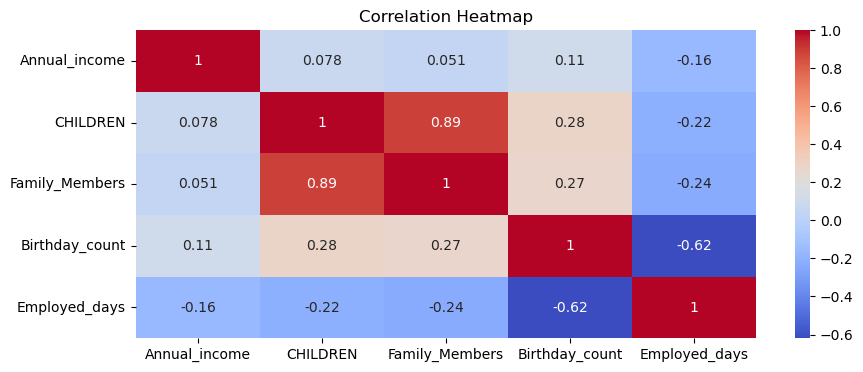

In [15]:
plt.figure(figsize = (10,4))
sns.heatmap(df[features].corr(), annot=True , cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

We observe that the variables `CHILDREN` and `Family_Members` are highly correlated (as one would expect). I am removing the `CHILDREN` variable, as I assume it is "contained" within the other. There are no collinearity issues with the remaining variables.

In [16]:
df.drop(['CHILDREN'], axis=1, inplace=True)

For `Annual_income`, let's look at what happens with observations containing null values ​​and zero income:

In [17]:
df[(df['Annual_income'].isnull()) | (df['Annual_income'] == 0)]

,GENDER,Car_Owner,Propert_Owner,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
3,F,Y,N,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,0,NaN,2,1
12,F,Y,Y,NaN,Working,Secondary / secondary special,Married,House / apartment,-18950.0,-1002,1,1,0,Cooking staff,2,1
27,F,N,Y,NaN,Pensioner,Secondary / secondary special,Married,House / apartment,-21832.0,365243,0,1,0,NaN,2,1
65,F,N,Y,NaN,Pensioner,Higher education,Separated,House / apartment,-24611.0,365243,0,0,0,NaN,1,1
76,M,N,Y,NaN,Working,Secondary / secondary special,Single / not married,House / apartment,-12947.0,-137,0,0,0,Laborers,2,1
107,M,Y,N,NaN,Commercial associate,Higher education,Single / not married,Municipal apartment,-11528.0,-606,0,1,1,High skill tech staff,1,1
125,F,N,Y,NaN,Pensioner,Secondary / secondary special,Married,House / apartment,-22655.0,365243,0,0,0,NaN,2,1
152,M,Y,Y,NaN,Commercial associate,Higher education,Married,House / apartment,-17841.0,-4305,1,1,0,Managers,4,1
185,F,Y,Y,NaN,Working,Secondary / secondary special,Married,House / apartment,-14222.0,-141,1,1,0,Cooking staff,3,0
215,F,N,Y,NaN,Commercial associate,Secondary / secondary special,Married,House / apartment,-19310.0,-1477,0,0,0,Cleaning staff,2,0


In [18]:
# Check employees > 0

df[df['Employed_days']>0].shape

(261, 16)

For `Annual_income`, we see 23 null values ​​and no observations equal to zero. We could impute these as 0 to be conservative, but I prefer to impute using the mean based on `Type_Income`; since there are no observations with zero income, I assume this is not operationally possible at this bank and would therefore make no practical sense.

In [19]:
# Group by 'Type_Income' and calculate the mean of 'Annual_income'

byincome_type = df.groupby('Type_Income')['Annual_income'].mean()

byincome_type

Type_Income
Commercial associate    234600.000000
Pensioner               155175.096226
State servant           211422.413793
Working                 181048.757306
Name: Annual_income, dtype: float64

In [20]:
# Impute using the mean based on Type_Income
# This assigns the mean of its own group to each null value — much more realistic:

df['Annual_income'] = df.groupby('Type_Income')['Annual_income'].transform(
    lambda x: x.fillna(x.mean())
)

In [21]:
df.isnull().sum()

GENDER               0
Car_Owner            0
Propert_Owner        0
Annual_income        0
Type_Income          0
EDUCATION            0
Marital_status       0
Housing_type         0
Birthday_count      22
Employed_days        0
Work_Phone           0
Phone                0
EMAIL_ID             0
Type_Occupation    488
Family_Members       0
label                0
dtype: int64

In [22]:
# Group by 'Type_Income' and calculate the mean of 'Birthday_count'

byincome_type = df.groupby('Type_Income')['Birthday_count'].mean()

byincome_type

Type_Income
Commercial associate   -14680.091160
Pensioner              -21695.471698
State servant          -15143.948276
Working                -14888.085568
Name: Birthday_count, dtype: float64

In [23]:
# Impute using the mean based on Type_Income
# This assigns the mean of its own group to each null value — much more realistic:

df['Birthday_count'] = df.groupby('Type_Income')['Birthday_count'].transform(
    lambda x: x.fillna(x.mean())
)

df.isnull().sum()

GENDER               0
Car_Owner            0
Propert_Owner        0
Annual_income        0
Type_Income          0
EDUCATION            0
Marital_status       0
Housing_type         0
Birthday_count       0
Employed_days        0
Work_Phone           0
Phone                0
EMAIL_ID             0
Type_Occupation    488
Family_Members       0
label                0
dtype: int64

#### Exploratory Data Analysis (EDA)

In [24]:
# Select numerical and categorical columns from the dataframe

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical: ", num_cols)
cat_cols = df.select_dtypes(include=[object]).columns.tolist()
print("Categorical: ", cat_cols)

Numerical:  ['Annual_income', 'Birthday_count', 'Employed_days', 'Work_Phone', 'Phone', 'EMAIL_ID', 'Family_Members', 'label']
Categorical:  ['GENDER', 'Car_Owner', 'Propert_Owner', 'Type_Income', 'EDUCATION', 'Marital_status', 'Housing_type', 'Type_Occupation']


In [25]:
# Convert binary variables to 'Yes' and 'No'

df[['Work_Phone', 'Phone', 'EMAIL_ID']] = df[['Work_Phone', 'Phone', 'EMAIL_ID']].replace({1: 'Yes', 0: 'No'})

df.head()

,GENDER,Car_Owner,Propert_Owner,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,M,Y,Y,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.00000,365243,No,No,No,NaN,2,1
1,F,Y,N,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.00000,-586,Yes,Yes,No,NaN,2,1
2,F,Y,N,315000.0,Commercial associate,Higher education,Married,House / apartment,-14680.09116,-586,Yes,Yes,No,NaN,2,1
3,F,Y,N,234600.0,Commercial associate,Higher education,Married,House / apartment,-13557.00000,-586,Yes,Yes,No,NaN,2,1
4,F,Y,N,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.00000,-586,Yes,Yes,No,NaN,2,1


In [26]:
# New seccion 

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical: ", num_cols)
cat_cols = df.select_dtypes(include=[object]).columns.tolist()
print("Categorical: ", cat_cols)

Numerical:  ['Annual_income', 'Birthday_count', 'Employed_days', 'Family_Members', 'label']
Categorical:  ['GENDER', 'Car_Owner', 'Propert_Owner', 'Type_Income', 'EDUCATION', 'Marital_status', 'Housing_type', 'Work_Phone', 'Phone', 'EMAIL_ID', 'Type_Occupation']


### cat_cols Treatment

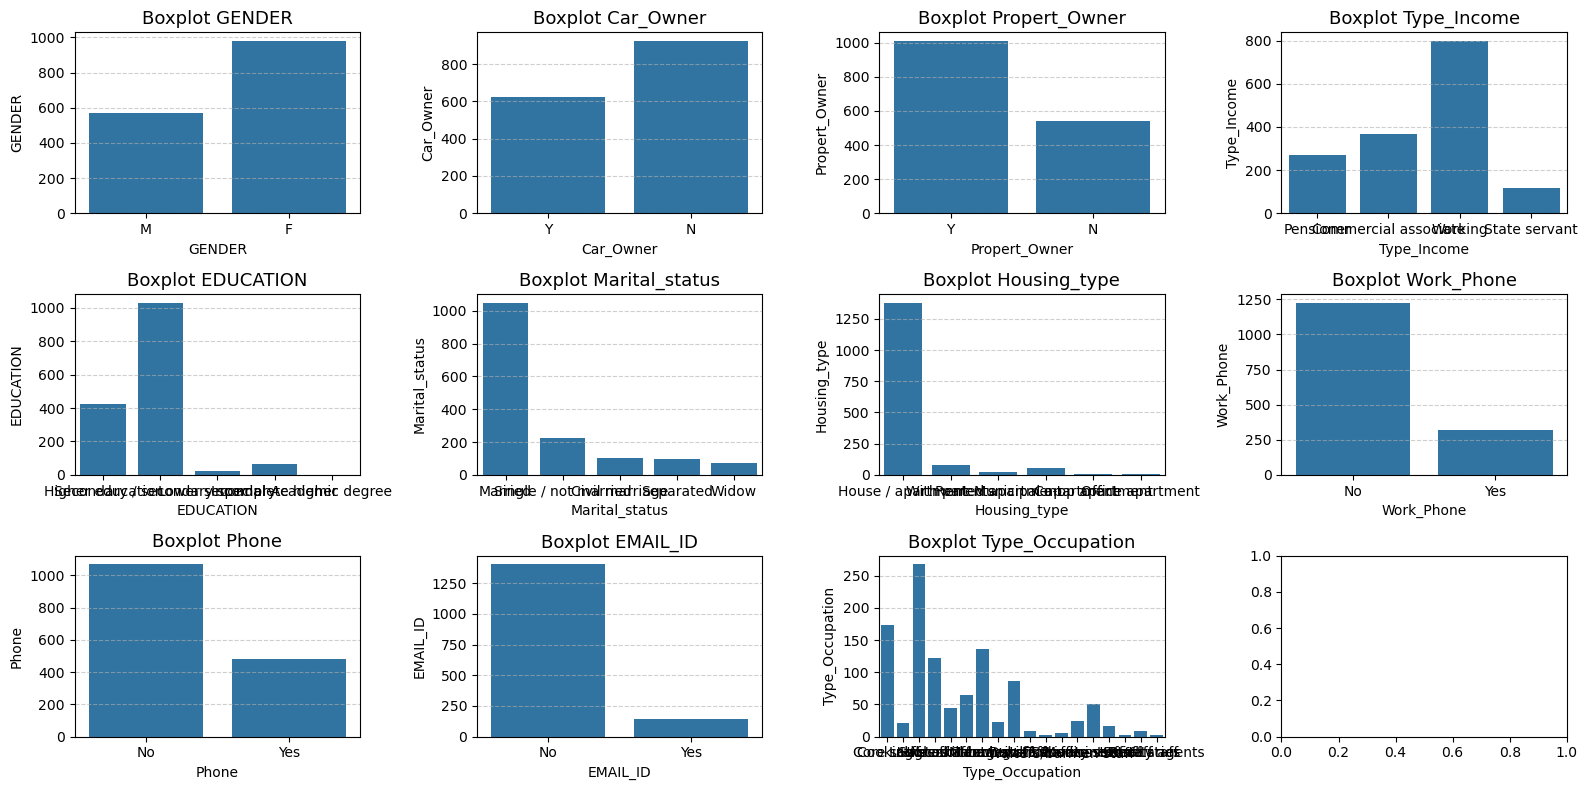

In [30]:
# Figure configuration (creating a grid of subplots)
fig, axes = plt.subplots(ncols=4, nrows=3, figsize=(16, 8))
axes = axes.flatten()

# 3. Iteration to plot each boxplot
for i, col in enumerate(cat_cols):
    sns.countplot(
        data=df, 
        x=col, 
        ax=axes[i], 
        legend=False      # Remove the repetitive legend
    )
    axes[i].set_title(f'Boxplot {col}', fontsize=13)
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### We see many variables with too many categories, so we are going to transform and group them to make them more meaningful.

In [31]:
df['Marital_status'].value_counts()

Marital_status
Married                 1049
Single / not married     227
Civil marriage           101
Separated                 96
Widow                     75
Name: count, dtype: int64

We are leaving the 'Marital_status' as is.

In [32]:
df['Housing_type'].value_counts()

Housing_type
House / apartment      1380
With parents             80
Municipal apartment      53
Rented apartment         21
Office apartment          9
Co-op apartment           5
Name: count, dtype: int64

In [33]:
# we group the categories 'Municipal apartment', 'Rented apartment', 'Office apartment', Co-op apartment
df['Housing_type'] = df['Housing_type'].replace({
    'Municipal apartment': 'Rent',
    'Rented apartment': 'Rent',
    'Office apartment': 'Rent',
    'Co-op apartment': 'Rent'
})

df['Housing_type'].value_counts()

Housing_type
House / apartment    1380
Rent                   88
With parents           80
Name: count, dtype: int64

In [34]:
# Verify the result
df.groupby('Housing_type')['label'].agg(['mean', 'count']).sort_values('count', ascending=False)

# The highest default rate is in the rent category

,mean,count
Housing_type,,
House / apartment,0.105797,1380
Rent,0.272727,88
With parents,0.062500,80


In [35]:
df.isnull().sum()

GENDER               0
Car_Owner            0
Propert_Owner        0
Annual_income        0
Type_Income          0
EDUCATION            0
Marital_status       0
Housing_type         0
Birthday_count       0
Employed_days        0
Work_Phone           0
Phone                0
EMAIL_ID             0
Type_Occupation    488
Family_Members       0
label                0
dtype: int64

In [36]:
df[(df['Type_Occupation'].isnull()) & (df['Employed_days'] > 0)]

,GENDER,Car_Owner,Propert_Owner,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,M,Y,Y,180000.000000,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,No,No,No,NaN,2,1
7,F,N,N,180000.000000,Pensioner,Secondary / secondary special,Married,House / apartment,-22134.0,365243,No,No,No,NaN,2,1
26,F,N,Y,112500.000000,Pensioner,Secondary / secondary special,Married,House / apartment,-21832.0,365243,No,Yes,No,NaN,2,1
27,F,N,Y,155175.096226,Pensioner,Secondary / secondary special,Married,House / apartment,-21832.0,365243,No,Yes,No,NaN,2,1
31,F,N,Y,112500.000000,Pensioner,Secondary / secondary special,Married,House / apartment,-21876.0,365243,No,Yes,Yes,NaN,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1509,F,Y,Y,157500.000000,Pensioner,Secondary / secondary special,Widow,House / apartment,-20432.0,365243,No,No,No,NaN,1,0
1511,F,N,Y,216000.000000,Pensioner,Higher education,Single / not married,House / apartment,-20388.0,365243,No,No,No,NaN,1,0
1514,F,N,N,69750.000000,Pensioner,Secondary / secondary special,Widow,Rent,-21986.0,365243,No,Yes,No,NaN,1,0
1525,F,Y,Y,175500.000000,Pensioner,Higher education,Married,House / apartment,-22077.0,365243,No,Yes,No,NaN,2,0


We observe that for some records where ``Type_Occupation`` is not reported, the ``Employed_days`` variable shows a positive value. The documentation indicates that ``Employed_days > 0`` signifies unemployment; therefore, I will assume that these cases essentially correspond to unemployed individuals. This makes sense, given that there is no category for "unemployed" within this variable.

In [37]:
df.loc[df[(df['Type_Occupation'].isnull()) & (df['Employed_days'] > 0)].index, 'Type_Occupation'] = "Unemployed"

In [38]:
# Check if we've built it correctly
df['Type_Occupation'].value_counts()

Type_Occupation
Laborers                 268
Unemployed               261
Core staff               174
Managers                 136
Sales staff              122
Drivers                   86
High skill tech staff     65
Medicine staff            50
Accountants               44
Security staff            25
Cleaning staff            22
Cooking staff             21
Private service staff     17
Low-skill Laborers         9
Secretaries                9
Waiters/barmen staff       5
HR staff                   3
IT staff                   2
Realty agents              2
Name: count, dtype: int64

In [39]:
df.isnull().sum()

GENDER               0
Car_Owner            0
Propert_Owner        0
Annual_income        0
Type_Income          0
EDUCATION            0
Marital_status       0
Housing_type         0
Birthday_count       0
Employed_days        0
Work_Phone           0
Phone                0
EMAIL_ID             0
Type_Occupation    227
Family_Members       0
label                0
dtype: int64

In [40]:
# For nullls values in the 'Type_Occupation' variable, we impute it as 'Unknown'.

df['Type_Occupation'] = df['Type_Occupation'].fillna('Unknown')

In [41]:
df['Type_Occupation'].value_counts()

Type_Occupation
Laborers                 268
Unemployed               261
Unknown                  227
Core staff               174
Managers                 136
Sales staff              122
Drivers                   86
High skill tech staff     65
Medicine staff            50
Accountants               44
Security staff            25
Cleaning staff            22
Cooking staff             21
Private service staff     17
Low-skill Laborers         9
Secretaries                9
Waiters/barmen staff       5
HR staff                   3
IT staff                   2
Realty agents              2
Name: count, dtype: int64

In [42]:
professional_mapping = {
    # White Collar
    'IT staff': 'White_Collar',
    'Managers': 'White_Collar',
    'Core staff': 'White_Collar',
    'Accountants': 'White_Collar',
    'Medicine staff': 'White_Collar',
    'High skill tech staff': 'White_Collar',
    'HR staff': 'White_Collar',

    # Blue Collar
    'Laborers': 'Blue_Collar',
    'Drivers': 'Blue_Collar',
    'Security staff': 'Blue_Collar',
    'Low-skill Laborers': 'Blue_Collar',

    # Sales
    'Sales staff': 'Sales_Services',
    'Realty agents': 'Sales_Services',
    'Secretaries': 'Sales_Services',

    # Hospitality
    'Cooking staff': 'Hospitality_Support',
    'Waiters/barmen staff': 'Hospitality_Support',
    'Cleaning staff': 'Hospitality_Support',

    # Individual categories ← here
    'Unemployed': 'Unemployed',
    'Unknown': 'Unknown',
}

df['Type_Occupation'] = df['Type_Occupation'].map(professional_mapping)

df.groupby('Type_Occupation')['label'].agg(['mean', 'count']).sort_values('mean', ascending=False)


,mean,count
Type_Occupation,,
Hospitality_Support,0.145833,48
Unemployed,0.134100,261
Blue_Collar,0.121134,388
White_Collar,0.113924,474
Unknown,0.096916,227
Sales_Services,0.075188,133


Regarding the ``EDUCATION`` variable, we will group together the two categories with the fewest observations to avoid introducing noise into our model. Notice that, due to their low frequency, these categories exhibit extreme values ​​in the response variable; we therefore prefer to eliminate this extreme variability caused by the limited number of observations. We group them with the category that is most similar in terms of education level.

In [43]:
df.groupby('EDUCATION')['label'].agg(['mean', 'count']).sort_values('count', ascending=False)

,mean,count
EDUCATION,,
Secondary / secondary special,0.105723,1031
Higher education,0.129108,426
Incomplete higher,0.073529,68
Lower secondary,0.285714,21
Academic degree,0.000000,2


In [44]:
df['EDUCATION'] = df['EDUCATION'].replace('Academic degree', 'Higher education')
df['EDUCATION'] = df['EDUCATION'].replace(['Lower secondary', 'Secondary / secondary special'], 'Secondary')
df.groupby('EDUCATION')['label'].agg(['mean', 'count']).sort_values('count', ascending=False)

,mean,count
EDUCATION,,
Secondary,0.109316,1052
Higher education,0.128505,428
Incomplete higher,0.073529,68


We check the state of the categorical variables.

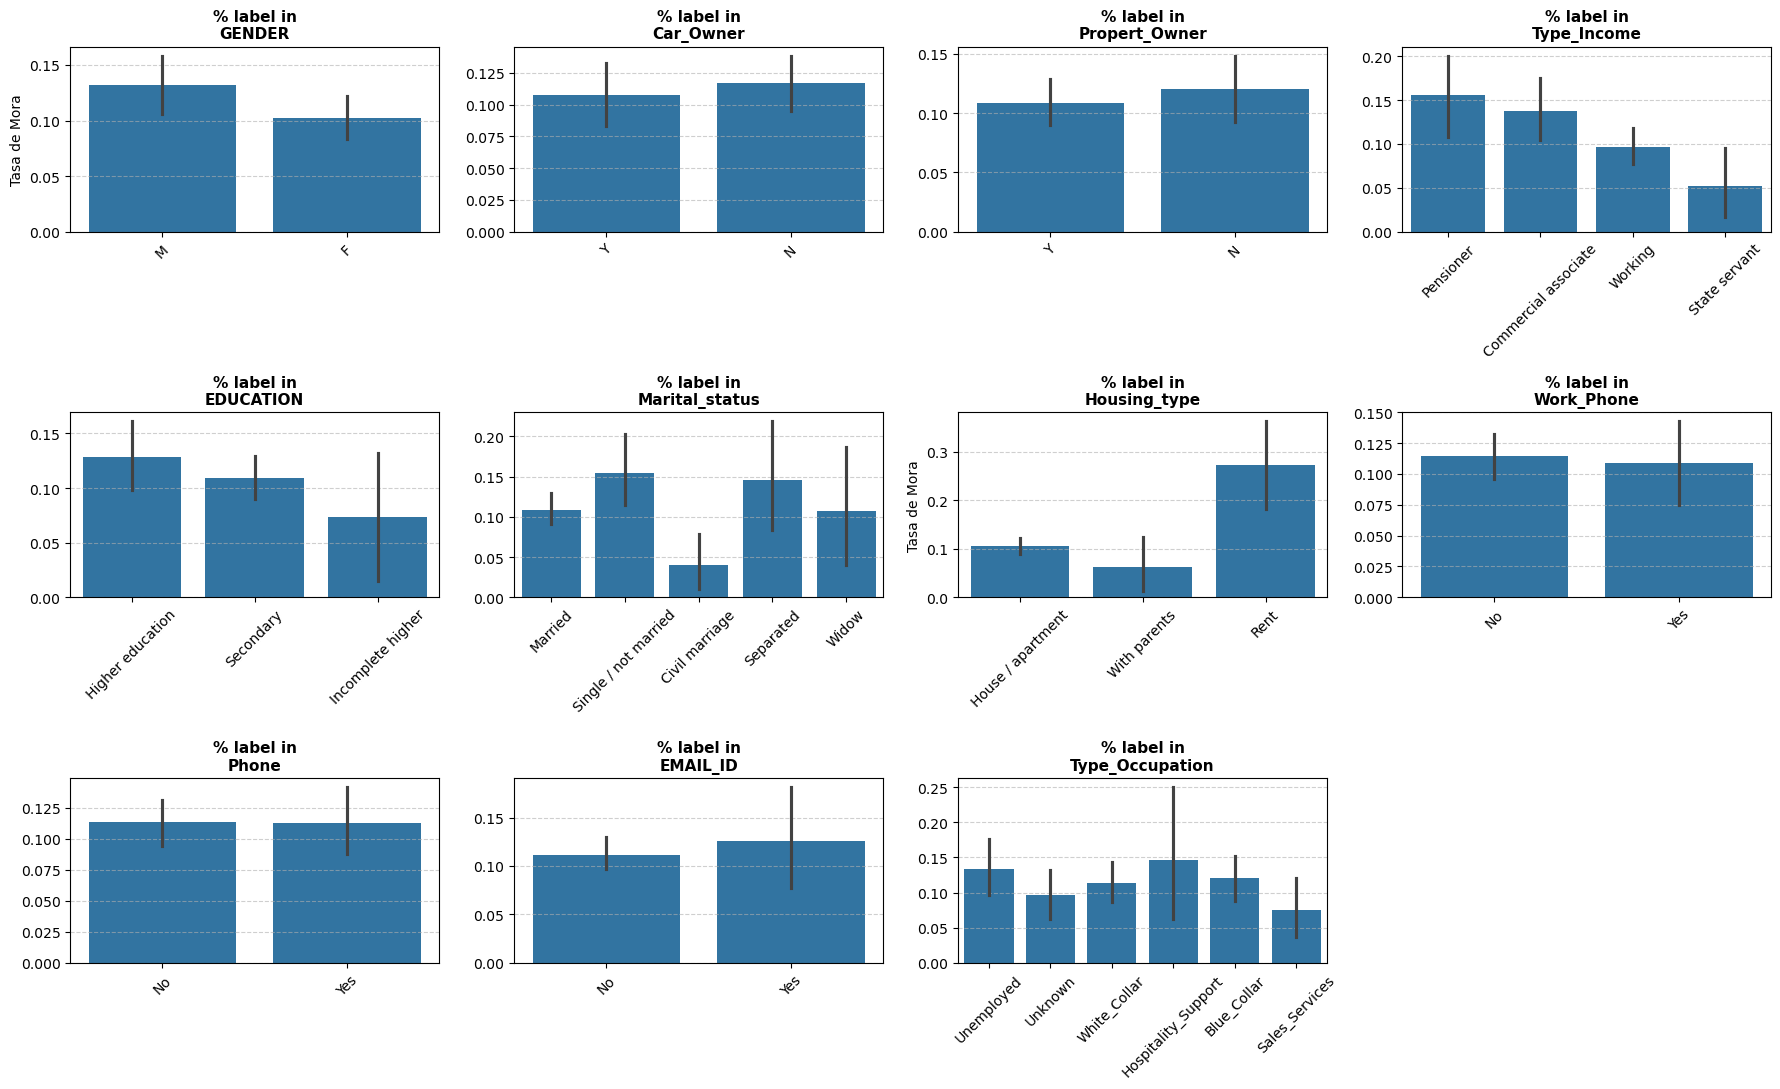

In [45]:
# Figure configuration (creating a grid of subplots)
fig, axes = plt.subplots(ncols=4, nrows=3, figsize=(18, 11))   # A little larger to fit the text
axes = axes.flatten()

# Iteration to plot each bar chart with the % (Delinquency Rate)
for i, col in enumerate(cat_cols):
    # sns.barplot calculates the mean by default (which, for 0/1 variables, is the percentage)
    sns.barplot(
        data=df, 
        x=col, 
        y='label',       # When setting the label for Y, calculate the proportion of 1s.
        ax=axes[i]
    )
    
    # We rotate the X-axis labels because they tend to overlap with categorical variables.
    axes[i].tick_params(axis='x', rotation=45) 
    
   # More precise titles and tags
    axes[i].set_title(f'% label in\n{col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Tasa de Mora' if i % 6 == 0 else '')  #We only show the Y-axis name in the first column
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# If you have fewer than 12 categorical variables, this removes the leftover empty subplots.
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [46]:
# Weliminated it due to low predictive capacity

df.drop(['Work_Phone', 'Phone', 'GENDER'], axis = 1, inplace=True)

### num_cols Treatment

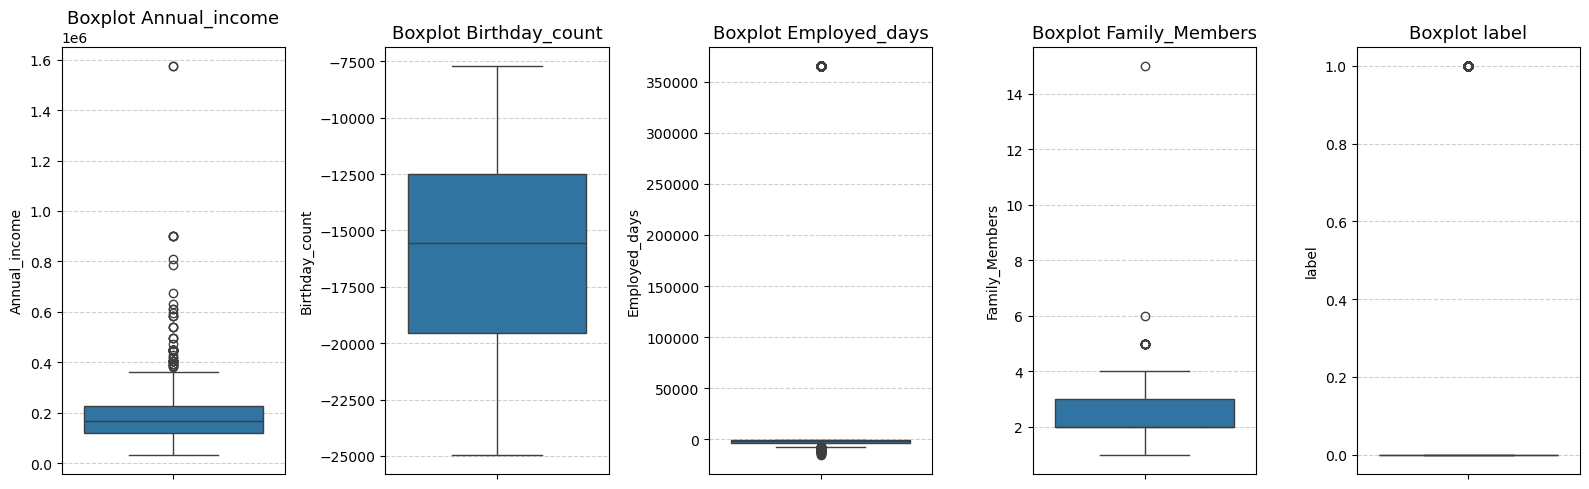

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Figure configuration (creating a grid of subplots)
fig, axes = plt.subplots(ncols=5, nrows=1, figsize=(16, 5))
axes = axes.flatten()

# 3. Iteration to plot each boxplot
for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df, 
        y=col, 
        ax=axes[i], 
        orient='v',
        legend=False      # Drop the repetitive legend
    )
    axes[i].set_title(f'Boxplot {col}', fontsize=13)
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [48]:
# identify outliers and use the 1st and 99th percentiles to trim extreme values

cols_outliers = ['Annual_income', 'Family_Members']

for col in cols_outliers:
    lower = df[col].quantile(0.01)  # percentil 1
    upper = df[col].quantile(0.99)  # percentil 99
    df[col] = df[col].clip(lower=lower, upper=upper)

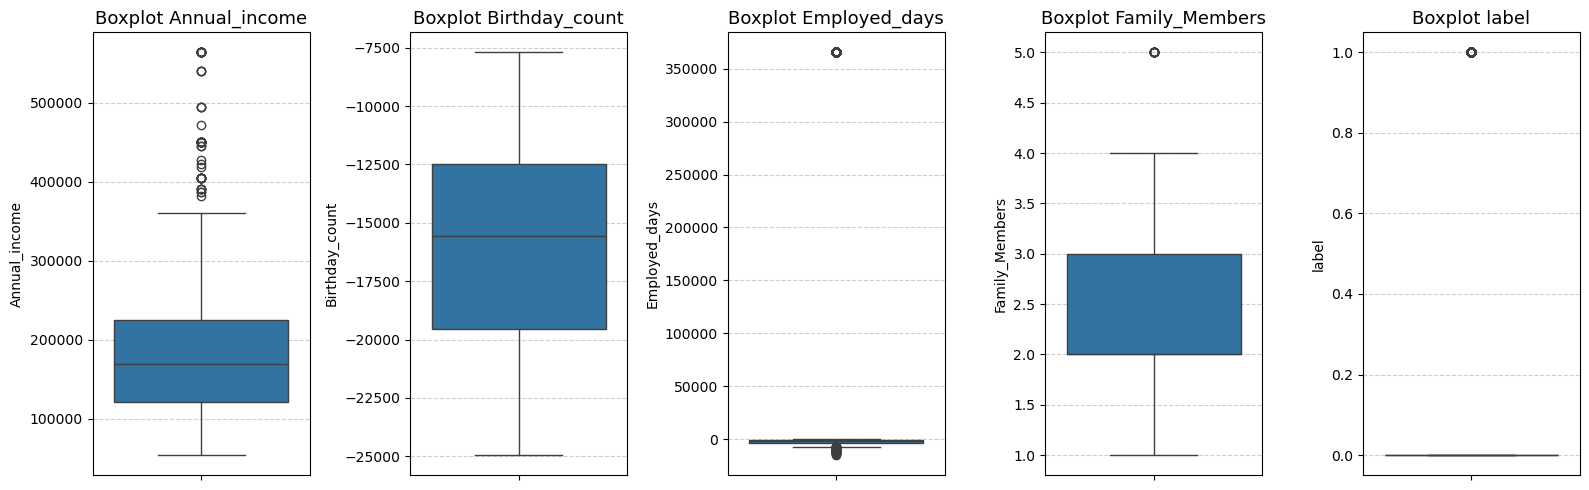

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Figure configuration (creating a grid of subplots)
fig, axes = plt.subplots(ncols=5, nrows=1, figsize=(16, 5))
axes = axes.flatten()

# 3. Iteration to plot each boxplot
for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df, 
        y=col, 
        ax=axes[i], 
        orient='v',
        legend=False      # Drop the repetitive legend
    )
    axes[i].set_title(f'Boxplot {col}', fontsize=13)
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [50]:
df['Employed_days'].describe()

count      1548.000000
mean      59364.689922
std      137808.062701
min      -14887.000000
25%       -3174.500000
50%       -1565.000000
75%        -431.750000
max      365243.000000
Name: Employed_days, dtype: float64

In [51]:
# 1. Replace positive values ​​(unemployed individuals) with 0, since an unemployed person does not generate value;
#  this reduces outliers.

df.loc[df['Employed_days'] > 0, 'Employed_days'] = 0

In [52]:
df['Employed_days'].describe()

count     1548.000000
mean     -2216.978682
std       2403.284736
min     -14887.000000
25%      -3174.500000
50%      -1565.000000
75%       -431.750000
max          0.000000
Name: Employed_days, dtype: float64

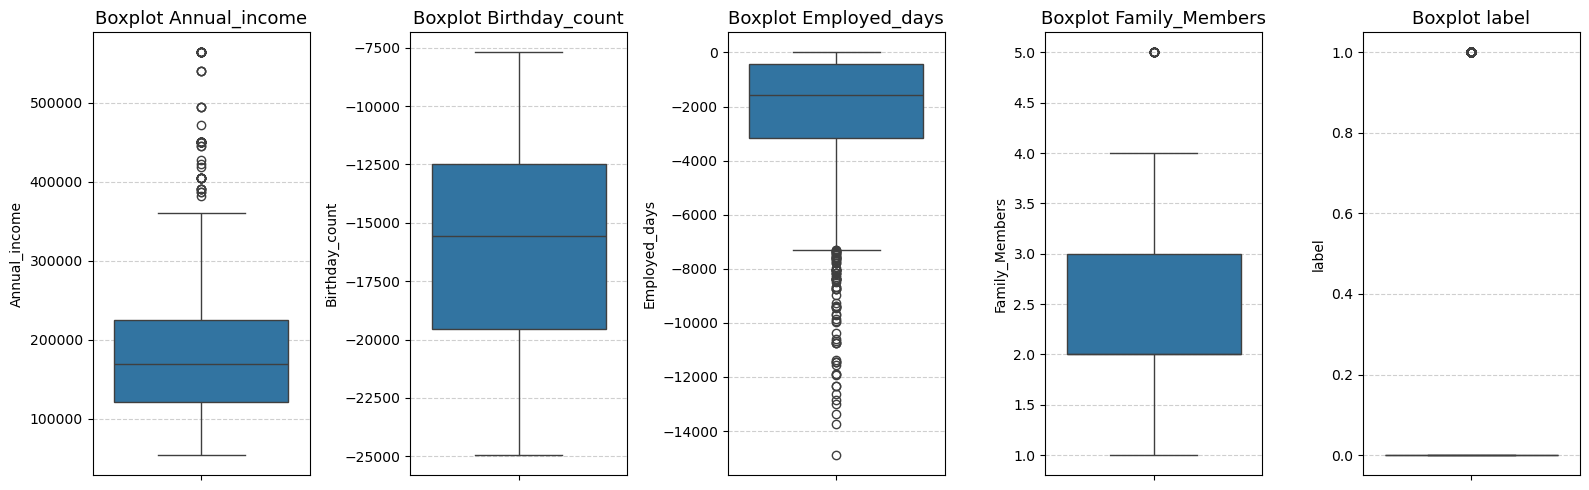

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Figure configuration (creating a grid of subplots)
fig, axes = plt.subplots(ncols=5, nrows=1, figsize=(16, 5))
axes = axes.flatten()

# 3. Iteration to plot each boxplot
for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df, 
        y=col, 
        ax=axes[i], 
        orient='v',
        legend=False      # Drop the repetitive legend
    )
    axes[i].set_title(f'Boxplot {col}', fontsize=13)
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Let us now examine the relationship between the numerical variables and our variable of interest.

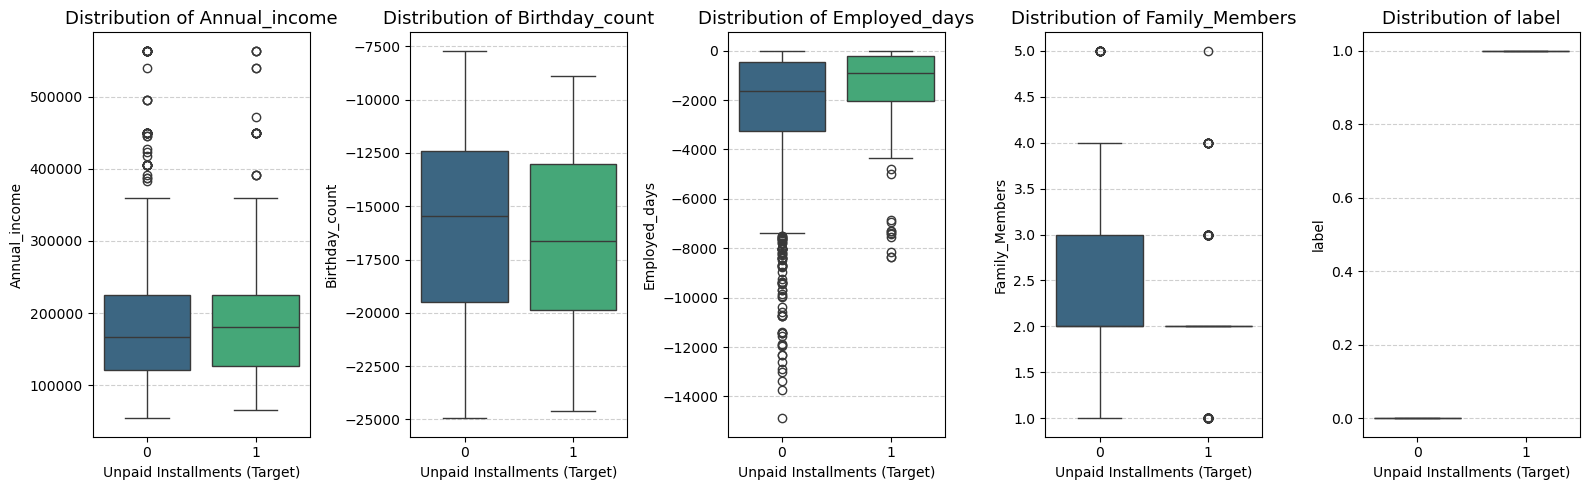

In [54]:
# Extract numerical variables again
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Figure configuration (creating a grid of subplots)
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(16, 5))
axes = axes.flatten()

# Iteration to plot each boxplot
for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df, 
        x='label', 
        y=col, 
        ax=axes[i], 
        palette='viridis',
        orient='v',
        hue='label',       # Add color by category
        legend=False      # Remove the repetitive legend
    )
    axes[i].set_title(f'Distribution of {col}', fontsize=13)
    axes[i].set_xlabel('Unpaid Installments (Target)')
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Surprisingly, there isn't much difference in income between good and bad payers, but there is regarding family members.

# Modeling

In [55]:
X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [56]:
# Create dummy variables
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# drop_first=True drops the first column to avoid the multicollinearity trap
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# Align the Train/Test columns
X_test = X_test.reindex(columns = X_train.columns, fill_value=0)

In [57]:
# We scale numerical variables
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Defition of the scaler
scaler = StandardScaler()

# We fit ONLY on the training set and transform both
# This prevents the model from knowing the full range of the test data in advance

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [58]:
X_train.head()

,Annual_income,Birthday_count,Employed_days,Family_Members,Car_Owner_Y,Propert_Owner_Y,Type_Income_Pensioner,Type_Income_State servant,Type_Income_Working,EDUCATION_Incomplete higher,...,Marital_status_Single / not married,Marital_status_Widow,Housing_type_Rent,Housing_type_With parents,EMAIL_ID_Yes,Type_Occupation_Hospitality_Support,Type_Occupation_Sales_Services,Type_Occupation_Unemployed,Type_Occupation_Unknown,Type_Occupation_White_Collar
730,-0.577886,0.308907,0.379775,-1.288092,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
100,-1.084337,0.248249,-1.887380,0.929720,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,False,True
619,-1.084337,1.393836,0.549271,0.929720,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
838,-1.268501,1.050661,-0.234084,-0.179186,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1419,-0.808091,-1.331501,0.916851,-1.288092,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False


In [59]:
from sklearn.metrics import roc_auc_score, recall_score, f1_score
from xgboost import XGBClassifier

# Model definitions (added class_weight='balanced' as seen before due to defaulters)
# Calculate balance ratio for XGBoost (non-defaulters/defaulters)
balance_ratio = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Tree": DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    "Random Forest Base": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=5,
        scale_pos_weight=balance_ratio,
        eval_metric='logloss',
        random_state=42
    ),
}

# Training and Evaluation
results = []
for name, model in models.items():
    # 1. Train
    model.fit(X_train, y_train)
    
    # 2. Predict (0 or 1) for Recall and F1
    preds = model.predict(X_test)
    
    # 3. Predict probabilities (percentage) for AUC
    probs = model.predict_proba(X_test)[:, 1]
    
    # 4. Calculate metrics
    auc = roc_auc_score(y_test, probs)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    # 5. Save results
    results.append({
        "Model": name, 
        "ROC-AUC": auc,
        "Recall": recall,
        "F1-Score": f1
    })

# Convert to DataFrame, multiply by 100 and sort by Recall (Defaulter-Hunting)
df_benchmark = pd.DataFrame(results).set_index("Model")
df_benchmark = (df_benchmark * 100).round(2)
df_benchmark.sort_values(by="Recall", ascending=False)

,ROC-AUC,Recall,F1-Score
Model,,,
Logistic,67.35,62.79,24.77
XGBoost,81.05,62.79,61.36
Tree,64.35,51.16,23.66
Random Forest Base,82.95,44.19,60.32


**Conclusion:** This project tackles credit risk classification, identifying which clients are likely to default (high risk) versus those likely to repay (low risk) — a critical task for financial institutions to minimize losses while maintaining healthy lending volume. After benchmarking four models, **XGBoost** stood out as the top performer, achieving a strong ROC-AUC of 81.05% and an F1-Score of 61.36%, while matching the best Recall (62.79%) among all models. This means XGBoost successfully identifies the majority of high-risk clients while keeping false positives low, striking the right balance between risk mitigation and business growth. These results demonstrate the value of gradient boosting methods and proper class balancing techniques in building production-ready credit risk models.